In [1]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn pandas tqdm

import os
import time
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from IPython.display import FileLink, display

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Torch version: 2.10.0+cu128
CUDA available: True


In [2]:
import os
import random
from PIL import Image
from tqdm.notebook import tqdm
from transformers import DPTImageProcessor, DPTForDepthEstimation

# NOTE: dataset path is unchanged from the plain EfficientNet-B5 baseline -- do not edit.
ORIGINAL_DATASET_ROOT = "/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong"
DEPTH_DATASET_ROOT = "/kaggle/working/tiny-genimage-depth"
DEPTH_BATCH_SIZE = 8

# Same setting as your plain EfficientNet-B5 baseline notebook (456x456 input,
# batch_size=8, accum_steps=2) so the only thing that changes between the two
# runs is the extra depth channel -- everything else stays comparable.
CONFIG = {
    "seed": 42,
    "image_size": 456,
    "batch_size": 8,
    "accum_steps": 2,
    "num_workers": 2,
    "num_epochs": 100,
    "learning_rate": 1e-4,
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])

CLASS_TO_IDX = {"ai": 0, "nature": 1}
IDX_TO_CLASS = {0: "ai", 1: "nature"}

# ==========================================
# 1. OFFLINE DEPTH EXTRACTION (resume-safe)
# ==========================================
# Scans per-file for what's actually missing (cheap once everything
# exists, since "pending" filters out files already there), and only
# spins up the DPT model if there is real work left to do. If you already
# ran the ResNet-50 or ViT-B/16 DPT notebook in this same Kaggle session,
# the cached depth maps under DEPTH_DATASET_ROOT are reused as-is and
# nothing needs to be re-extracted.
def depth_map_to_uint8(depth_2d):
    d_min, d_max = depth_2d.min(), depth_2d.max()
    if d_max - d_min > 1e-6:
        return ((depth_2d - d_min) / (d_max - d_min) * 255).astype("uint8")
    return np.zeros_like(depth_2d, dtype="uint8")

pending_work = {}
total_pending = 0
for split_name in ["train", "val"]:
    src_dir = os.path.join(ORIGINAL_DATASET_ROOT, split_name)
    dest_dir = os.path.join(DEPTH_DATASET_ROOT, split_name)

    for class_name in os.listdir(src_dir):
        class_src = os.path.join(src_dir, class_name)
        class_dest = os.path.join(dest_dir, class_name)
        if not os.path.isdir(class_src):
            continue
        os.makedirs(class_dest, exist_ok=True)

        pending = [
            n for n in os.listdir(class_src)
            if not os.path.exists(os.path.join(class_dest, os.path.splitext(n)[0] + ".png"))
        ]
        if pending:
            pending_work[(split_name, class_name, class_src, class_dest)] = pending
            total_pending += len(pending)

if total_pending > 0:
    print(f"{total_pending} images missing depth maps. Loading Intel DPT-Large model for extraction...")
    processor = DPTImageProcessor.from_pretrained("Intel/dpt-large")
    dpt_model = DPTForDepthEstimation.from_pretrained("Intel/dpt-large").to(DEVICE)
    dpt_model.eval()

    for (split_name, class_name, class_src, class_dest), pending in pending_work.items():
        for i in tqdm(range(0, len(pending), DEPTH_BATCH_SIZE), desc=f"Extracting Depth - {split_name}/{class_name}"):
            batch_names = pending[i:i + DEPTH_BATCH_SIZE]
            batch_images, valid_names = [], []
            for name in batch_names:
                try:
                    batch_images.append(Image.open(os.path.join(class_src, name)).convert("RGB"))
                    valid_names.append(name)
                except Exception as e:
                    pass

            if not batch_images:
                continue

            inputs = processor(
                images=batch_images,
                size={"height": 384, "width": 384},
                keep_aspect_ratio=False,
                return_tensors="pt"
            ).to(DEVICE)

            with torch.no_grad():
                predicted_depth = dpt_model(**inputs).predicted_depth

            for img, name, depth in zip(batch_images, valid_names, predicted_depth):
                prediction = torch.nn.functional.interpolate(
                    depth.unsqueeze(0).unsqueeze(0),
                    size=img.size[::-1],
                    mode="bicubic",
                    align_corners=False
                )
                formatted = depth_map_to_uint8(prediction.squeeze().cpu().numpy())
                Image.fromarray(formatted).save(os.path.join(class_dest, os.path.splitext(name)[0] + ".png"))

    del dpt_model
    del processor
    torch.cuda.empty_cache()
    print("Extraction complete. DPT cleared from GPU memory.")
else:
    print("Depth maps found for every image. Skipping extraction.")


# ==========================================
# 2. MATCH PAIRS & BUILD 4-CHANNEL DATALOADER
# ==========================================
# Samples are listed train/ai, train/nature, val/ai, val/nature with sorted
# filenames -- the same order ImageFolder + ConcatDataset gave the baseline --
# so the seed-42 70/15/15 split below puts the same images in train/val/test.
all_samples = []
for split in ["train", "val"]:
    for class_name, label in CLASS_TO_IDX.items():
        src_class_dir = os.path.join(ORIGINAL_DATASET_ROOT, split, class_name)
        depth_class_dir = os.path.join(DEPTH_DATASET_ROOT, split, class_name)

        for fname in sorted(os.listdir(src_class_dir)):
            rgb_path = os.path.join(src_class_dir, fname)
            depth_path = os.path.join(depth_class_dir, os.path.splitext(fname)[0] + ".png")
            if os.path.exists(depth_path):
                all_samples.append((rgb_path, depth_path, label))

# Fail loudly instead of silently training on a shrunken dataset if any
# depth maps are still missing.
EXPECTED_TOTAL = sum(
    len(os.listdir(os.path.join(ORIGINAL_DATASET_ROOT, split, class_name)))
    for split in ["train", "val"] for class_name in CLASS_TO_IDX
)
assert len(all_samples) == EXPECTED_TOTAL, (
    f"Matched {len(all_samples)} RGB-D pairs but expected {EXPECTED_TOTAL}. "
    "Some depth maps are missing -- rerun the extraction cell before continuing."
)

class RGBDDataset(Dataset):
    def __init__(self, sample_list, is_train=True, img_size=224):
        self.samples = sample_list
        self.is_train = is_train
        self.img_size = img_size
        self.rgb_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.depth_norm = transforms.Normalize(mean=[0.5], std=[0.5])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rgb_path, depth_path, label = self.samples[idx]
        rgb_img = Image.open(rgb_path).convert("RGB").resize((self.img_size, self.img_size), Image.BILINEAR)
        depth_img = Image.open(depth_path).convert("L").resize((self.img_size, self.img_size), Image.BILINEAR)

        if self.is_train and random.random() < 0.5:
            rgb_img = rgb_img.transpose(Image.FLIP_LEFT_RIGHT)
            depth_img = depth_img.transpose(Image.FLIP_LEFT_RIGHT)

        rgb_t = self.rgb_norm(transforms.functional.to_tensor(rgb_img))
        depth_t = self.depth_norm(transforms.functional.to_tensor(depth_img))
        return torch.cat([rgb_t, depth_t], dim=0), label

total_len = len(all_samples)
train_subset, val_subset, test_subset = random_split(
    all_samples,
    [int(0.7 * total_len), int(0.15 * total_len), total_len - int(0.7 * total_len) - int(0.15 * total_len)],
    generator=torch.Generator().manual_seed(CONFIG["seed"])
)

train_dataset = RGBDDataset(list(train_subset), is_train=True, img_size=CONFIG["image_size"])
val_dataset = RGBDDataset(list(val_subset), is_train=False, img_size=CONFIG["image_size"])
test_dataset = RGBDDataset(list(test_subset), is_train=False, img_size=CONFIG["image_size"])

print(f"Total matched RGB-D pairs: {total_len}")
print(f"Train pairs: {len(train_dataset)} | Val pairs: {len(val_dataset)} | Test pairs: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

5000 images missing depth maps. Loading Intel DPT-Large model for extraction...


preprocessor_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/942 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.37G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

...

Extracting Depth - train/nature:   0%|          | 0/250 [00:00<?, ?it/s]

Extracting Depth - train/ai:   0%|          | 0/250 [00:00<?, ?it/s]

Extracting Depth - val/nature:   0%|          | 0/63 [00:00<?, ?it/s]

Extracting Depth - val/ai:   0%|          | 0/63 [00:00<?, ?it/s]

Extraction complete. DPT cleared from GPU memory.
Total matched RGB-D pairs: 5000
Train pairs: 3500 | Val pairs: 750 | Test pairs: 750


In [3]:
def build_4channel_efficientnet_b5(num_classes=2):
    model = models.efficientnet_b5(weights=None)

    # Replace classifier head for 2 classes (AI vs Real) -- same as the
    # plain EfficientNet-B5 baseline.
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    # EfficientNet-B5's stem conv is features[0][0] (Conv2d 3->48, 3x3,
    # stride 2, no bias; BatchNorm + SiLU follow it). Same idea as ResNet's
    # conv1 / ViT's conv_proj swap: keep every other setting and just widen
    # in_channels from 3 to 4 so it can take RGB + Depth.
    old_conv = model.features[0][0]
    new_conv = nn.Conv2d(
        in_channels=4,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias is not None
    )
    # Give the new stem the same init torchvision's EfficientNet gives every
    # conv (kaiming_normal_, fan_out), so it starts like the baseline's stem.
    nn.init.kaiming_normal_(new_conv.weight, mode="fan_out")
    if new_conv.bias is not None:
        nn.init.zeros_(new_conv.bias)
    model.features[0][0] = new_conv
    return model

# Re-seed right before building so the weight init doesn't depend on whether
# the DPT extraction ran in the cell above.
set_seed(CONFIG["seed"])
model = build_4channel_efficientnet_b5(num_classes=2).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
# Same schedule as the plain EfficientNet-B5 baseline: halve LR after 1 epoch
# without val_loss improvement.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"4-Channel EfficientNet-B5 initialized on {DEVICE}.")
print(f"Trainable parameters: {num_trainable:,}")

4-Channel EfficientNet-B5 initialized on cuda.
Trainable parameters: 28,345,314


In [4]:
scaler = torch.amp.GradScaler('cuda')

def run_epoch(model, loader, criterion, optimizer=None, accum_steps=1):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    if is_training:
        optimizer.zero_grad()

    torch.set_grad_enabled(is_training)
    for step, (images, labels) in enumerate(loader):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            outputs = model(images)
            raw_loss = criterion(outputs, labels)
            loss = raw_loss / accum_steps if is_training else raw_loss

        if is_training:
            scaler.scale(loss).backward()
            if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        total_loss += raw_loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    torch.set_grad_enabled(True)

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy

best_val_acc = 0.0
best_val_loss = float("inf")
CHECKPOINT_PATH = "/kaggle/working/rgbd_efficientnet_b5_best_checkpoint.pth"

history_train_loss, history_val_loss = [], []
history_train_acc, history_val_acc = [], []

for epoch in range(1, CONFIG["num_epochs"] + 1):
    start = time.time()
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, accum_steps=CONFIG["accum_steps"])
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step(val_loss)

    history_train_loss.append(train_loss)
    history_val_loss.append(val_loss)
    history_train_acc.append(train_acc)
    history_val_acc.append(val_acc)

    # Same combined checkpoint rule your EfficientNet-B5 baseline used (save
    # on val_acc improving, else on val_loss improving; best_val_loss is
    # updated on every improvement), kept identical so the RGB vs RGB-D
    # comparison isn't skewed by a different model-selection rule.
    saved = False
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        saved = True
    elif val_loss < best_val_loss:
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        saved = True

    if val_loss < best_val_loss:
        best_val_loss = val_loss

    elapsed = time.time() - start
    chkpt_msg = " [*Saved Best Checkpoint]" if saved else ""
    print(f"Epoch {epoch:03d}/{CONFIG['num_epochs']} "
          f"| train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
          f"| {elapsed:.1f}s{chkpt_msg}")

# Load the best saved checkpoint for testing
model.load_state_dict(torch.load(CHECKPOINT_PATH))
print("\nLoaded best checkpoint for evaluation.")

Epoch 001/100 | train_loss=0.6164 train_acc=0.6737 | val_loss=0.6943 val_acc=0.5080 | 202.0s [*Saved Best Checkpoint]
Epoch 002/100 | train_loss=0.5099 train_acc=0.7560 | val_loss=0.5531 val_acc=0.7000 | 174.8s [*Saved Best Checkpoint]
Epoch 003/100 | train_loss=0.4703 train_acc=0.7877 | val_loss=1.3152 val_acc=0.7120 | 172.8s [*Saved Best Checkpoint]
Epoch 004/100 | train_loss=0.4389 train_acc=0.8063 | val_loss=0.4085 val_acc=0.8253 | 172.4s [*Saved Best Checkpoint]
Epoch 005/100 | train_loss=0.4133 train_acc=0.8220 | val_loss=0.3604 val_acc=0.8547 | 172.9s [*Saved Best Checkpoint]
Epoch 006/100 | train_loss=0.3992 train_acc=0.8226 | val_loss=0.4328 val_acc=0.8040 | 173.0s
Epoch 007/100 | train_loss=0.3902 train_acc=0.8237 | val_loss=0.3436 val_acc=0.8627 | 172.6s [*Saved Best Checkpoint]
Epoch 008/100 | train_loss=0.3899 train_acc=0.8280 | val_loss=0.3493 val_acc=0.8587 | 172.8s
Epoch 009/100 | train_loss=0.3784 train_acc=0.8403 | val_loss=0.3726 val_acc=0.8373 | 173.0s
Epoch 010/100

In [5]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

pos_lbl = CLASS_TO_IDX.get("ai", 0)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, pos_lbl].cpu().tolist()
        preds = outputs.argmax(dim=1).cpu().tolist()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

print("===== Classification Report (Test Set - RGB-D EfficientNet-B5) =====")
print(classification_report(all_labels, all_preds, target_names=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]]))

fpr, tpr, thresholds = roc_curve(all_labels, all_probs, pos_label=pos_lbl)
roc_auc = auc(fpr, tpr)

output_dir = "/kaggle/working/results"
os.makedirs(output_dir, exist_ok=True)

acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="binary", pos_label=pos_lbl
)

results_row = {
    "dataset": "tiny_genimage_rgbd_wukong",
    "model": "rgbd_efficientnet_b5",
    "num_epochs": len(history_train_loss),
    "train_images": len(train_dataset),
    "test_images": len(test_dataset),
    "test_accuracy": round(acc, 4),
    "test_precision": round(precision, 4),
    "test_recall": round(recall, 4),
    "test_f1_score": round(f1, 4),
    "test_auc": round(roc_auc, 4)
}

results_df = pd.DataFrame([results_row])
display(results_df)

RESULTS_CSV_PATH = os.path.join(output_dir, "rgbd_efficientnet_b5_test_results.csv")
results_df.to_csv(RESULTS_CSV_PATH, index=False)

FINAL_MODEL_PATH = os.path.join(output_dir, "rgbd_efficientnet_b5_best_model.pth")
shutil.copy(CHECKPOINT_PATH, FINAL_MODEL_PATH)

print("\n===== Download Links =====")
display(FileLink(RESULTS_CSV_PATH))
display(FileLink(FINAL_MODEL_PATH))

===== Classification Report (Test Set - RGB-D EfficientNet-B5) =====
              precision    recall  f1-score   support

          ai       0.89      0.85      0.87       370
      nature       0.86      0.90      0.88       380

    accuracy                           0.88       750
   macro avg       0.88      0.88      0.88       750
weighted avg       0.88      0.88      0.88       750



,dataset,model,num_epochs,train_images,test_images,test_accuracy,test_precision,test_recall,test_f1_score,test_auc
0,tiny_genimage_rgbd_wukong,rgbd_efficientnet_b5,100,3500,750,0.876,0.8924,0.8514,0.8714,0.9575



===== Download Links =====


/kaggle/working/results/rgbd_efficientnet_b5_test_results.csv

/kaggle/working/results/rgbd_efficientnet_b5_best_model.pth

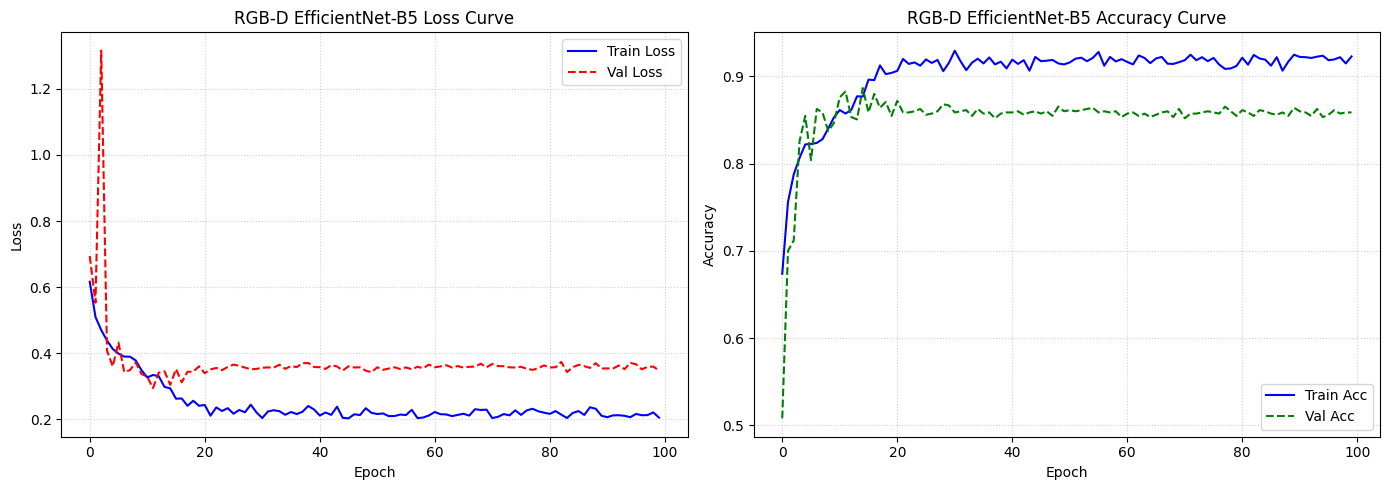

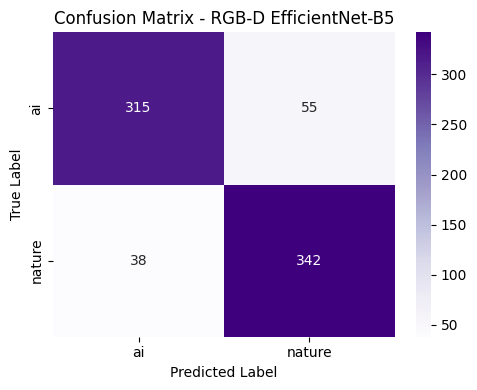

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_train_loss, label="Train Loss", color="blue")
axes[0].plot(history_val_loss, label="Val Loss", color="red", linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("RGB-D EfficientNet-B5 Loss Curve")
axes[0].legend()
axes[0].grid(True, linestyle=":", alpha=0.6)

axes[1].plot(history_train_acc, label="Train Acc", color="blue")
axes[1].plot(history_val_acc, label="Val Acc", color="green", linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("RGB-D EfficientNet-B5 Accuracy Curve")
axes[1].legend()
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "rgbd_efficientnet_b5_training_curves.png"), dpi=150)
plt.show()

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]],
            yticklabels=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - RGB-D EfficientNet-B5")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "rgbd_efficientnet_b5_confusion_matrix.png"), dpi=150)
plt.show()